In [27]:
# ==========================================================
# PERBAIKAN PATH UNTUK KAGGELEHUB
# ==========================================================

import kagglehub
import os

# 1. Download dataset (Jika sudah download, ini akan langsung mengambil dari cache)
path = kagglehub.dataset_download("techsash/waste-classification-data")

# 2. Deteksi otomatis struktur folder
# Dataset ini biasanya memiliki folder 'DATASET' di dalamnya lagi
base_path = os.path.join(path, 'DATASET', 'TRAIN')

# Cek apakah path benar-benar ada
if not os.path.exists(base_path):
    # Jika struktur berbeda, kita cari folder TRAIN di dalam path download
    print("Mencari folder TRAIN secara manual...")
    for root, dirs, files in os.walk(path):
        if 'TRAIN' in dirs:
            base_path = os.path.join(root, 'TRAIN')
            break

print(f"Path yang digunakan sekarang: {base_path}")

# 3. Sekarang jalankan listdir
classes = ['O', 'R']
stats = []

for c in classes:
    folder_path = os.path.join(base_path, c)
    if os.path.exists(folder_path):
        num_images = len(os.listdir(folder_path))
        stats.append({'Class': c, 'Count': num_images})
    else:
        print(f"Peringatan: Folder {c} tidak ditemukan di {folder_path}")

# Lanjutkan ke bagian visualisasi (plt.figure dst...) sama seperti sebelumnya

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Path yang digunakan sekarang: /kaggle/input/waste-classification-data/DATASET/TRAIN


In [28]:
train_path = '/content/DATASET/TRAIN'
# Lanjutkan dengan os.listdir(train_path) untuk menghitung jumlah gambar...

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset ditemukan di: /kaggle/input/waste-classification-data/DATASET/TRAIN

--- Distribusi Dataset ---
  Class  Count
0     O  12565
1     R   9999


/tmp/ipykernel_5276/1654913074.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_stats, x='Class', y='Count', palette='viridis')


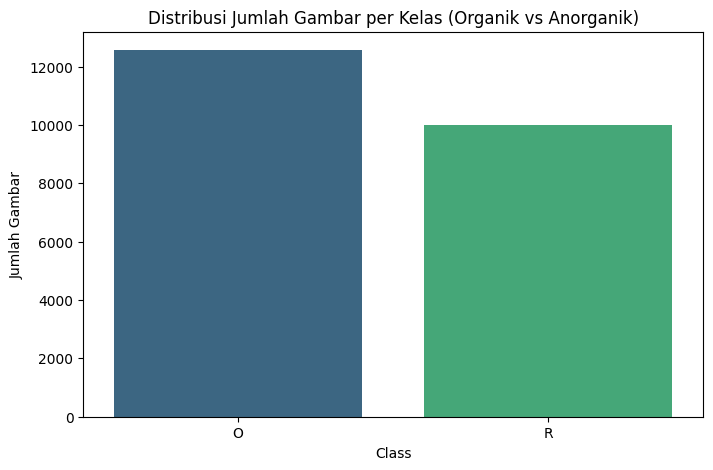

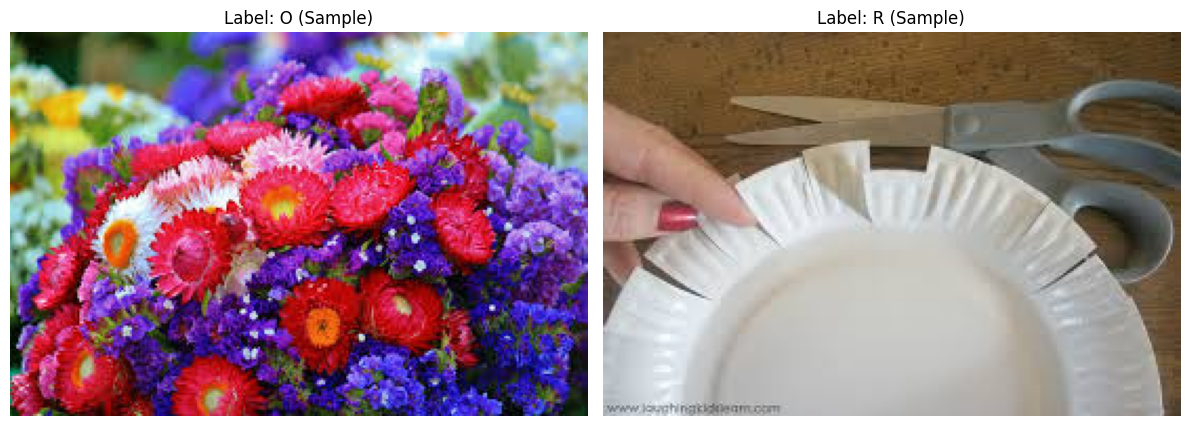


Resolusi asli gambar contoh: 275x183 piksel
Justifikasi: Gambar akan di-resize ke 224x224 untuk MobileNetV2.


In [30]:
# ==========================================================
# JUDUL: Exploratory Data Analysis (EDA) - Visual Waste Classifier
# KELOMPOK: [Isi Nama Kelompok]
# MINGGU 2: Akuisisi & Persiapan Data (Kagglehub Version)
# ==========================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import kagglehub
from tensorflow.keras.preprocessing.image import load_img

# 1. Unduh dataset menggunakan kagglehub
# Jika sudah pernah diunduh, ini hanya akan mengambil path-nya saja (cepat)
path = kagglehub.dataset_download("techsash/waste-classification-data")

# 2. Deteksi otomatis struktur folder TRAIN
# Berdasarkan dataset techsash, strukturnya adalah: path + /DATASET/TRAIN
base_path = os.path.join(path, 'DATASET', 'TRAIN')

# Validasi apakah folder benar-benar ada
if not os.path.exists(base_path):
    print("Struktur folder berbeda, mencari folder TRAIN...")
    for root, dirs, files in os.walk(path):
        if 'TRAIN' in dirs:
            base_path = os.path.join(root, 'TRAIN')
            break

print(f"Dataset ditemukan di: {base_path}")

# 3. Analisis Distribusi Kelas
classes = ['O', 'R']
stats = []

for c in classes:
    folder_path = os.path.join(base_path, c)
    if os.path.exists(folder_path):
        num_images = len(os.listdir(folder_path))
        stats.append({'Class': c, 'Count': num_images})
    else:
        print(f"Peringatan: Folder {c} tidak ditemukan di {folder_path}")

df_stats = pd.DataFrame(stats)
print("\n--- Distribusi Dataset ---")
print(df_stats)

# Visualisasi Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=df_stats, x='Class', y='Count', palette='viridis')
plt.title('Distribusi Jumlah Gambar per Kelas (Organik vs Anorganik)')
plt.ylabel('Jumlah Gambar')
plt.show()

# 4. Visualisasi Sampel Gambar
plt.figure(figsize=(12, 6))
for i, c in enumerate(classes):
    folder_path = os.path.join(base_path, c)
    img_name = os.listdir(folder_path)[0]
    img_path = os.path.join(folder_path, img_name)

    img = load_img(img_path)
    plt.subplot(1, 2, i+1)
    plt.imshow(img)
    plt.title(f"Label: {c} (Sample)")
    plt.axis('off')
plt.tight_layout()
plt.show()

# 5. Analisis Dimensi Gambar
sample_img_path = os.path.join(base_path, 'O', os.listdir(os.path.join(base_path, 'O'))[0])
sample_img = cv2.imread(sample_img_path)
height, width, channels = sample_img.shape
print(f"\nResolusi asli gambar contoh: {width}x{height} piksel")
print(f"Justifikasi: Gambar akan di-resize ke 224x224 untuk MobileNetV2.")

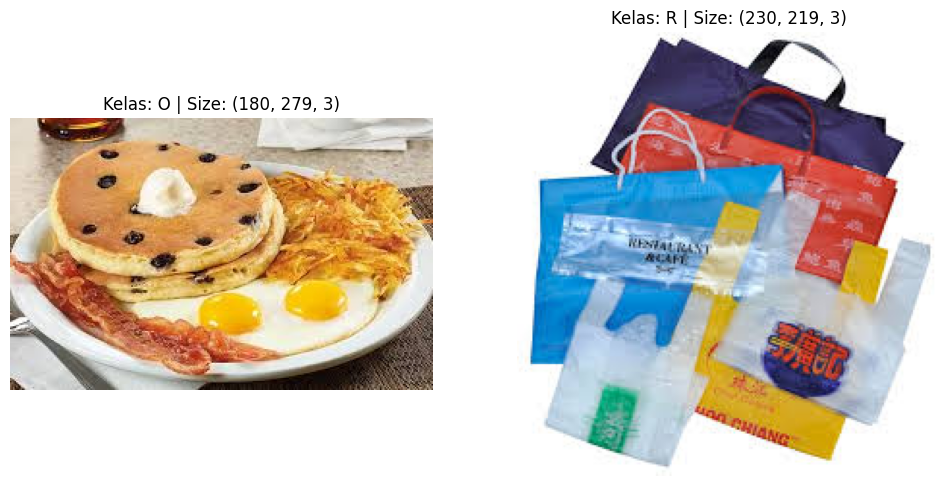


--- Statistik Resolusi Gambar (50 Sampel) ---
      Height   Width
min    136.0  141.00
max    282.0  371.00
mean   204.1  251.96


In [31]:
# 1. Menampilkan Sampel Gambar secara Acak
import matplotlib.image as mpimg
import random

plt.figure(figsize=(12, 8))
for i, c in enumerate(classes):
    folder_path = os.path.join(base_path, c)
    random_img = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, random_img)

    plt.subplot(1, 2, i+1)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(f"Kelas: {c} | Size: {img.shape}")
    plt.axis('off')
plt.show()

# 2. Analisis Resolusi (Justifikasi Resizing)
resolutions = []
for c in classes:
    folder_path = os.path.join(base_path, c)
    for img_name in os.listdir(folder_path)[:50]: # Ambil 50 sampel saja agar cepat
        img = cv2.imread(os.path.join(folder_path, img_name))
        if img is not None:
            resolutions.append(img.shape[:2])

res_df = pd.DataFrame(resolutions, columns=['Height', 'Width'])
print("\n--- Statistik Resolusi Gambar (50 Sampel) ---")
print(res_df.describe().loc[['min', 'max', 'mean']])